In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("TensorFlow is working!")

TensorFlow version: 2.21.0
TensorFlow is working!


In [2]:
from pathlib import Path

# Location of our X-ray dataset
data_path = Path("../data/image/chest_xray")

# Count images in each folder
for split in ["train", "test", "val"]:
    normal_count = len(list((data_path / split / "NORMAL").glob("*.jpeg")))
    pneumonia_count = len(list((data_path / split / "PNEUMONIA").glob("*.jpeg")))

    print(f"{split.upper()}:")
    print(f"  NORMAL: {normal_count}")
    print(f"  PNEUMONIA: {pneumonia_count}")
    print()

TRAIN:
  NORMAL: 1341
  PNEUMONIA: 3875

TEST:
  NORMAL: 234
  PNEUMONIA: 390

VAL:
  NORMAL: 8
  PNEUMONIA: 8



Image size: (2090, 1858)
Image mode: L


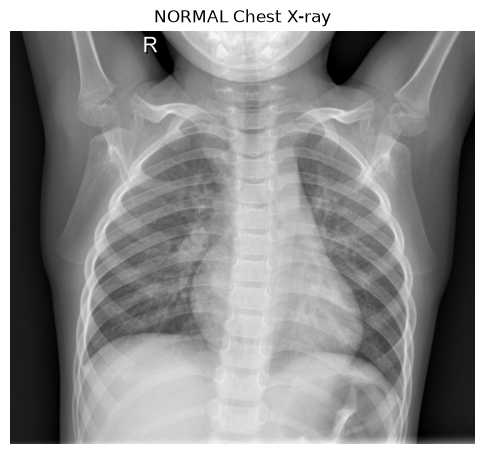

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

# Pick one NORMAL X-ray
normal_image_path = next(
    (data_path / "train" / "NORMAL").glob("*.jpeg")
)

# Load the image
image = Image.open(normal_image_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

# Display the X-ray
plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title("NORMAL Chest X-ray")
plt.axis("off")
plt.show()

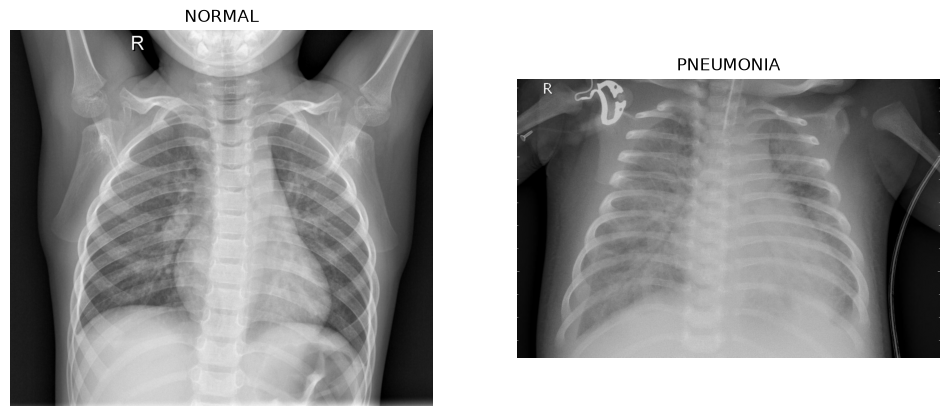

In [4]:
# Get one NORMAL and one PNEUMONIA image

normal_path = next(
    (data_path / "train" / "NORMAL").glob("*.jpeg")
)

pneumonia_path = next(
    (data_path / "train" / "PNEUMONIA").glob("*.jpeg")
)

normal_image = Image.open(normal_path)
pneumonia_image = Image.open(pneumonia_path)

# Display both images
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(normal_image, cmap="gray")
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pneumonia_image, cmap="gray")
plt.title("PNEUMONIA")
plt.axis("off")

plt.show()

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size for our CNN
IMG_SIZE = (224, 224)

# Batch size
BATCH_SIZE = 32

# Training data generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True
)

# Test/validation data should NOT be augmented
test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Image generators created successfully!")

Image generators created successfully!


In [6]:
# Create a generator with a validation split
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    validation_split=0.20
)

# Training images
train_generator = train_val_datagen.flow_from_directory(
    str(data_path / "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="grayscale",
    subset="training",
    shuffle=True,
    seed=42
)

# Validation images
validation_generator = train_val_datagen.flow_from_directory(
    str(data_path / "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="grayscale",
    subset="validation",
    shuffle=False,
    seed=42
)

print("Training and validation generators created!")
print("Class mapping:", train_generator.class_indices)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Training and validation generators created!
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [7]:
# Get one batch of images and labels
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel value range:", images.min(), "to", images.max())
print("First 10 labels:", labels[:10])

Image batch shape: (32, 224, 224, 1)
Label batch shape: (32,)
Pixel value range: 0.0 to 1.0
First 10 labels: [0. 0. 1. 1. 1. 1. 0. 1. 1. 1.]


In [8]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

cnn_model = Sequential([
    Input(shape=(224, 224, 1)),

    # First convolution block
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    # Second convolution block
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    # Third convolution block
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    # Convert feature maps into a vector
    Flatten(),

    # Fully connected layer
    Dense(128, activation="relu"),
    Dropout(0.5),

    # Binary classification
    Dense(1, activation="sigmoid")
])

print("CNN model created successfully!")

CNN model created successfully!


In [9]:
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [10]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Get the labels used by the training generator
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        np.unique(train_generator.classes),
        class_weights_array
    )
}

print("Class weights:", class_weights)

Class weights: {0: 1.9445479962721341, 1: 0.6730645161290323}


In [11]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation performance stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the CNN
history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

print("CNN training completed!")

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.7618 - loss: 0.4726 - val_accuracy: 0.9051 - val_loss: 0.2350
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 1515s 12s/step - accuracy: 0.8970 - loss: 0.2674 - val_accuracy: 0.9051 - val_loss: 0.2383
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 815ms/step - accuracy: 0.9145 - loss: 0.2216 - val_accuracy: 0.8984 - val_loss: 0.2210
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 125s 952ms/step - accuracy: 0.9142 - loss: 0.2073 - val_accuracy: 0.9060 - val_loss: 0.2369
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 128s 978ms/step - accuracy: 0.9279 - loss: 0.1843 - val_accuracy: 0.9473 - val_loss: 0.1522
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9353 - loss: 0.1664 - val_accuracy: 0.9214 - val_loss: 0.1971
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 131s 998ms/step - accuracy: 0.9329 - loss: 0.1645 - val_accuracy: 0.9195 - val_loss: 0.1836
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9399 - loss: 0.1

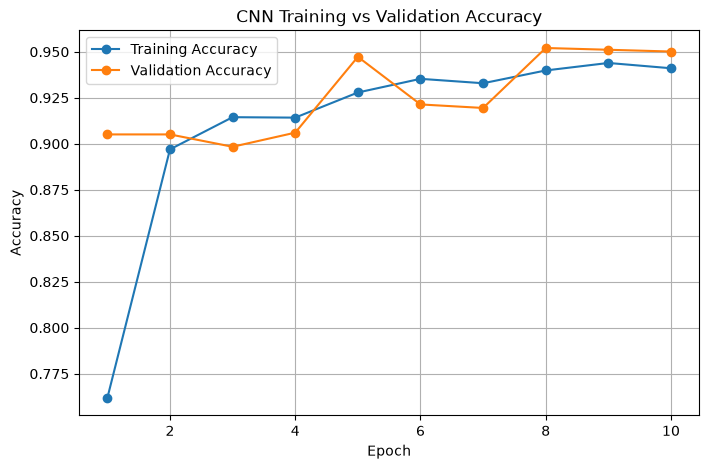

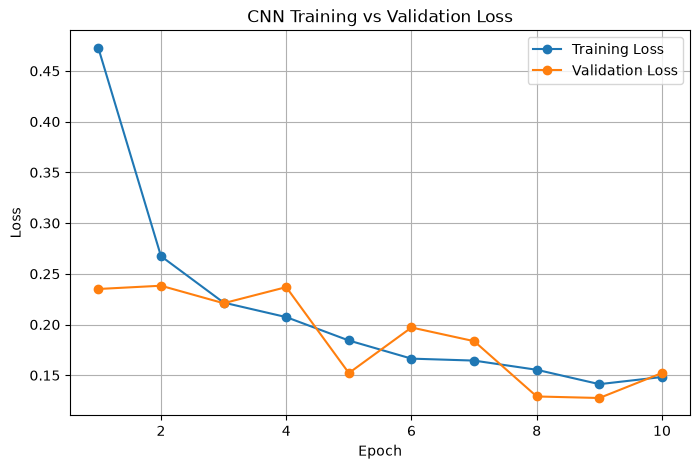

In [12]:
import matplotlib.pyplot as plt

# Get training history
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(train_accuracy) + 1)

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracy, marker="o", label="Training Accuracy")
plt.plot(epochs, val_accuracy, marker="o", label="Validation Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker="o", label="Training Loss")
plt.plot(epochs, val_loss, marker="o", label="Validation Loss")
plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Test data generator
test_generator = test_datagen.flow_from_directory(
    str(data_path / "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="grayscale",
    shuffle=False
)

print("Test generator created!")
print("Test class mapping:", test_generator.class_indices)

Found 624 images belonging to 2 classes.
Test generator created!
Test class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [14]:
# Evaluate the CNN on completely unseen test images

test_loss, test_accuracy = cnn_model.evaluate(test_generator)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 347ms/step - accuracy: 0.8654 - loss: 0.4211
Test Loss: 0.4211
Test Accuracy: 86.54 %


In [15]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Generate probability predictions
y_probability = cnn_model.predict(test_generator)

# Convert probabilities into class predictions
y_pred = (y_probability >= 0.5).astype(int).ravel()

# Get the true labels
y_true = test_generator.classes

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step
Accuracy : 0.8654
Precision: 0.8312
Recall   : 0.9846
F1-score : 0.9014

Confusion Matrix:
[[156  78]
 [  6 384]]


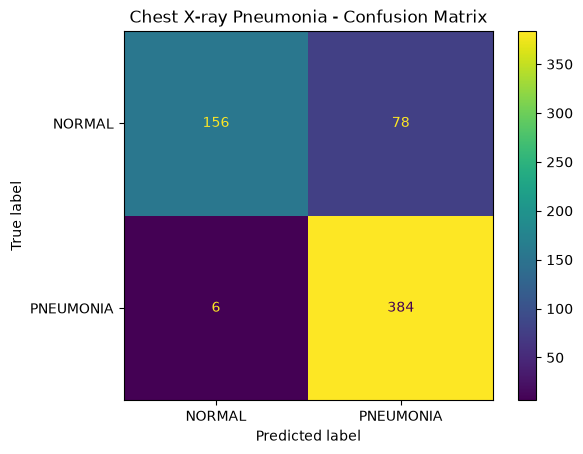

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot()
plt.title("Chest X-ray Pneumonia - Confusion Matrix")
plt.show()

In [17]:
from sklearn.metrics import roc_auc_score

# Calculate ROC-AUC using the predicted probabilities
roc_auc = roc_auc_score(y_true, y_probability.ravel())

print("X-ray ROC-AUC:", round(roc_auc, 4))

X-ray ROC-AUC: 0.9439


In [18]:
# Save the trained CNN model

cnn_model.save("../models/xray_pneumonia_model.keras")

print("X-ray pneumonia model saved successfully!")

X-ray pneumonia model saved successfully!


In [19]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_xray_model = load_model(
    "../models/xray_pneumonia_model.keras"
)

print("X-ray model loaded successfully!")

X-ray model loaded successfully!


In [20]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Pick one unseen test X-ray
test_image_path = next(
    (data_path / "test" / "PNEUMONIA").glob("*.jpeg")
)

# Load and resize the image
test_image = load_img(
    test_image_path,
    target_size=IMG_SIZE,
    color_mode="grayscale"
)

# Convert image to NumPy array
test_array = img_to_array(test_image)

# Normalize pixel values
test_array = test_array / 255.0

# Add batch dimension
test_array = np.expand_dims(test_array, axis=0)

# Predict using the SAVED model
probability = loaded_xray_model.predict(test_array)[0][0]

if probability >= 0.5:
    prediction = "PNEUMONIA"
else:
    prediction = "NORMAL"

print("Image:", test_image_path.name)
print("Model Prediction:", prediction)
print("Pneumonia Probability:", round(float(probability) * 100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Image: person100_bacteria_475.jpeg
Model Prediction: PNEUMONIA
Pneumonia Probability: 95.62 %
